# Un ejemplo rápido de uso de word embeddings estáticos
La idea de esta notebook es poder ilustrar una de las formas posibles de uso de word embeddings. En particular, vamos a utilizarlos para detectar algunos estereotipos culturales.

En general, la utilidad de los word embeddings es clara: marcaron u salto cualitativo en la evolución de los NLP. Es importante tener en cuenta que estos modelos (y todos los modelos de lenguaje) tienden a reproducir sesgos o estereotipos culturales. Esto puede ser un problema si se utilizan en aplicaciones ensibles.

Sin embargo, para las ciencias sociales abrió una posibilidad interesante: analizar y cuantificar tales sesgos y estereotipos culturales. Al analizar un corpus grande y representativo de una lengua o de una sociedad específica, las incrustaciones de palabras pueden usarse para identificar cómo *ciertas formas de desigualdad* se expresan y reproducen en el lenguaje.

Vamos a tratar de reproducir algunos de los ejercicios que están en el texto de [Koslowski et al]() y que mencionamos en la parte teórica.

Como vimos, utiliza word2vec y otros modelos basados ​​en varios corpus para generar incrustaciones de palabras durante el período 1900-2000. - Construyen una serie de dimensiones independientes (clase, riqueza, género, estatus, etc.) y las comparan con diferentes dimensiones culturales. La siguiente figura ilustra esto:

<div>
<img src="https://drive.google.com/uc?export=view&id=1BI6kiSDcJig5n83I1C_Fuc_j8vckVpiV" width="500"/>
</div>


- El primer panel (A) muestra la construcción de la dimensión "afluencia". Se construye calculando la diferencia entre vectores de pares de palabras: $rico - pobre$, $invaluable-inútil$, etc. Estos vectores luego se promedian, lo que da como resultado la dimensión de "opulencia".
- A continuación, se calcula la similitud coseno entre esta dimensión de "afluencia" y diferentes términos relacionados, por ejemplo, con bienes culturales.
- Esto les permite "proyectarlos" en la dimensión de la "opulencia". El panel B muestra la posición de los diferentes deportes.
- Así, "camping" y "boxing" parecen fuertemente asociados con el polo de pobreza, mientras que "golf" y "tenis" están asociados con el polo rico de la dimensión "opulencia".
-  También realizan diferentes comparaciones con otras dimensiones culturales a lo largo del tiempo y varias validaciones con fuentes externas (como una encuesta de consumo cultural).

La idea, entonces, es reproducir rápidamente algunas de estas correlaciones para tratar de entender un uso posible de los embeddings estáticos.

# Un embedding en castellano: Spansish Billion Word
Este recurso consta de un corpus sin anotaciones del idioma español de casi 1.500 millones de palabras, compiladas a partir de diferentes corpus y recursos de la web; y un conjunto de vectores de palabras (o incrustaciones), creados a partir de este corpus utilizando el algoritmo word2vec, proporcionado por el paquete gensim. Estas incrustaciones se evaluaron traduciendo al español el conjunto de pruebas de relación de palabras de word2vec.

El corpus limpio está disponible públicamente para descargar como archivo de texto sin formato (espejo). Los vectores de palabras también están disponibles para descargar en formato binario (espejo) de word2vec y en formato de texto (espejo).

Lo armó Cristian Cardellino y pueden encontrar detalles sobre el corpus y el modo de entrenamiento [aquí](https://crscardellino.github.io/SBWCE/).

Primero, descargamos el corpus y lo descomprimimos:

In [1]:
!wget https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz
!gunzip ./SBW-vectors-300-min5.bin.gz

--2026-04-12 21:43:42--  https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz
Resolving cs.famaf.unc.edu.ar (cs.famaf.unc.edu.ar)... 200.16.17.55
Connecting to cs.famaf.unc.edu.ar (cs.famaf.unc.edu.ar)|200.16.17.55|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1123304474 (1.0G) [application/x-gzip]
Saving to: ‘SBW-vectors-300-min5.bin.gz’

SBW-vectors-300-min 100%[===================>]   1.05G  16.1MB/s    in 69s     

2026-04-12 21:44:52 (15.5 MB/s) - ‘SBW-vectors-300-min5.bin.gz’ saved [1123304474/1123304474]



In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.5 MB/s eta 0:00:00


Cargamos las librerías

In [4]:
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from numpy.linalg import norm
from gensim.models import FastText
from scipy import spatial

## Definimos diccionarios de palabras

Por ejemplo, para la dimensión de género vamos a usar los siguientes pares de palabras:

```python
[('hombre','mujer'),('hombres','mujeres'), ('él', 'ella'), ('ellos', 'ellas'), ('niño', 'niña'),('niños', 'niñas'), ('macho', 'hembra'), ('masculino', 'femenino')]
```

Para la dimensión de "pobreza" las siguientes:
```python
 'pobreza':[('rico','pobre'), ('riqueza','pobreza'), ('costoso','económico'), ('caro', 'barato'), ('opulento', 'indigente'), ('invaluable','despreciable'),
                       ('solvente','insolvente'), ('desarrollado', 'subdesarrollado'), ('central','marginal'), ('opulencia','indigencia')]
```

Cada palabra expresa un polo de la dimensión.

Son dos listas de tuplas. Las insertamos dentro de un dict cuya `key`es el nombre de la dimensión.


                       



In [5]:
independ = {'genero':[('hombre','mujer'),('hombres','mujeres'), ('él', 'ella'), ('ellos', 'ellas'), ('niño', 'niña'),('niños', 'niñas'), ('macho', 'hembra'), ('masculino', 'femenino')],
                       'pobreza':[('rico','pobre'), ('riqueza','pobreza'), ('costoso','económico'), ('caro', 'barato'), ('opulento', 'indigente'), ('invaluable','despreciable'),
                       ('solvente','insolvente'), ('desarrollado', 'subdesarrollado'), ('central','marginal'), ('opulencia','indigencia')]}

Luego, hacemos lo mismo con las dimensiones "dependientes": comida, deportes, ocupación, música, etc.

In [26]:
cultural = {'0_deportes': ['fútbol', 'rubgy', 'tenis', 'turf', 'automovilismo', 'boxeo', 'golf', 'basketball', 'hockey', 'baseball'],
           '5_ocupaciones_masc':['empresario', 'peón', 'carpintero', 'médico', 'maestro','ingeniero', 'periodista', 'peluquero', 'abogado', 'niñero', 'enfermero', 'plomero', 'científico', 'gerente'],
           '6_ocupaciones_fem':['empresaria','carpintera', 'médica', 'maestra','ingeniera', 'periodista', 'peluquera', 'abogada', 'niñera', 'enfermera', 'plomera', 'científica', 'gerente'],
           '1_comida':['cerveza','arroz','fideos','polenta','lentejas', 'salmón','atún','hamburguesa', 'torta', 'ensalada', 'asado', 'ravioles', 'caviar', 'trufas', 'cognac', 'champagne', 'champignon', 'azafrán'],
           '2_musica':['rock', 'pop', 'funk', 'jazz', 'trap', 'cumbia', 'tango', 'chacarera', 'chamamé', 'vidala', 'milonga', 'ópera', 'rap'],
           '3_transporte':['bicicleta', 'patineta', 'patines', 'monopatín', 'limusina', 'camión', 'camioneta', 'motocicleta', 'yate', 'jeep', 'bus', 'tren', 'tranvía'],
           '4_marcas_autos':['volkswagen', 'ford', 'chevrolet', 'ferrari' , 'porsche', "audi"]}

Ahora cargamos los modelos:

In [7]:
w2v = KeyedVectors.load_word2vec_format('./SBW-vectors-300-min5.bin', binary=True)
#w2v = Word2Vec.load('./SBW-vectors-300-min5.bin')
#ft = FastText.load('./cc.es.300.bin')

## Definimos algunas funciones auxiliares

In [11]:
def get_diff(word1, word2, wv):
  return(wv[word1] - wv[word2]) # Calcula la diferencia entre dos vectores

def get_cosine(array1, array2):
  return(1 - spatial.distance.cosine(array1, array2)) #Devuelve la distancia coseno entre dos arrays

def get_cosine_dimentions(wv, target_dict, dim_label, indepen_vect):
  """
  Toma como input un modelo de word embeddings, un dict con las dimennsiones a evaluar y la etiqueta de la dimensión a evaluar.
  Devuelve un dataframe en formato "wide" con tres columnas: la dimensión, la palabra y la distancia coseno
  """
  d = {item:get_cosine(indepen_vect, wv[item]) for item in target_dict[dim_label]}
  df = pd.Series(d).sort_values().reset_index(name='cosine')
  df['dim'] = dim_label
  df.rename({'index':'word'},axis='columns', inplace=True)
  cols = list(df.columns)
  cols = [cols[-1]] + cols[:-1]
  df = df[cols]
  return(df)

La función get_cosine_dimentions toma un modelo de word embeddings (`v`), un diccionario de dimensiones culturales (`target_dict`), una etiqueta de dimensión específica (`dim_label`) y un vector que representa una dimensión independiente (`indepen_vect`) como entrada.

- Calcula las distancias coseno:

    Crea un diccionario d donde las claves son las palabras de la dimensión cultural especificada por dim_label (por ejemplo, `fútbol`, `rugby`,
    `tenis` si `dim_label` es `deportes`).
    Para cada palabra, calcula la distancia coseno entre su vector en el modelo de word embeddings (`wv[item]`) y el vector de la dimensión independiente (`indepen_vect`) utilizando la función `get_cosine`.

- Crea un DataFrame:
    Convierte el diccionario d en una serie de Pandas y la ordena por los valores de distancia coseno.
    Crea un DataFrame a partir de esta serie, agregando una columna `dim` con la etiqueta de la dimensión y renombrando la columna de índice a `word`.
    Reordena las columnas para que `dim` sea la primera columna.

- Devuelve el DataFrame:
    La función devuelve el DataFrame resultante, que contiene la dimensión, la palabra y la distancia coseno correspondiente para cada palabra en la dimensión cultural especificada.

## Calculamos las dimensiones de pobreza y género
Se calculan como el promedio de cada una de las diferencias entre los pares de palabras opuestos. Así la dimensión "pobreza" es el promedio de todas estas diferencias

$$\vec{pobre} - \vec{rico}$$
$$\vec{pobreza} - \vec{riqueza}$$
$$\vec{costoso} - \vec{económico}$$
$$ ... $$
$$\vec{indigencia} - \vec{opulencia}$$


In [13]:
pob_dimention = np.mean(np.array([get_diff(value[0], value[1], w2v) for value in independ['pobreza']]),axis=0)
genero_dimention = np.mean(np.array([get_diff(value[0], value[1], w2v) for value in independ['genero']]),axis=0)

## Cruzamos contra las dimensiones culturales
Luego calculamos la correlación que existe entre el vector promedio de "género" y de "pobreza" contra cada una de las palabras de las dimensiones dependientes.

La correlación se calcula con una métrica llamada [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity)

In [14]:
df = []
for c in cultural.keys():
  # Pass pob_dimention explicitly as indepen_vect
  d = get_cosine_dimentions(wv=w2v, target_dict=cultural, dim_label=c, indepen_vect=pob_dimention)
  df.append(d)

df = pd.concat(df, axis=0)

El código anterior itera sobre las claves del diccionario cultural, que son las diferentes dimensiones culturales como `deportes`, `ocupaciones', `comida`, etc.

Para cada dimensión c, se llama a la función `get_cosine_dimentions` para calcular la distancia coseno entre el vector de la dimensión independiente (como pobreza o género) y cada palabra en la dimensión cultural c.

El resultado de `get_cosine_dimentions` es un DataFrame d que contiene la distancia coseno para cada palabra en la dimensión cultural. Este DataFrame se agrega a la lista `df`.

Finalmente, todos los DataFrames en la lista `df` se concatenan en un solo DataFrame usando `pd.concat(df, axis=0)`. Esto crea un DataFrame que contiene las distancias coseno para todas las palabras en todas las dimensiones culturales.


## Finalmente, ploteamos los resultados

In [15]:
from plotnine import *

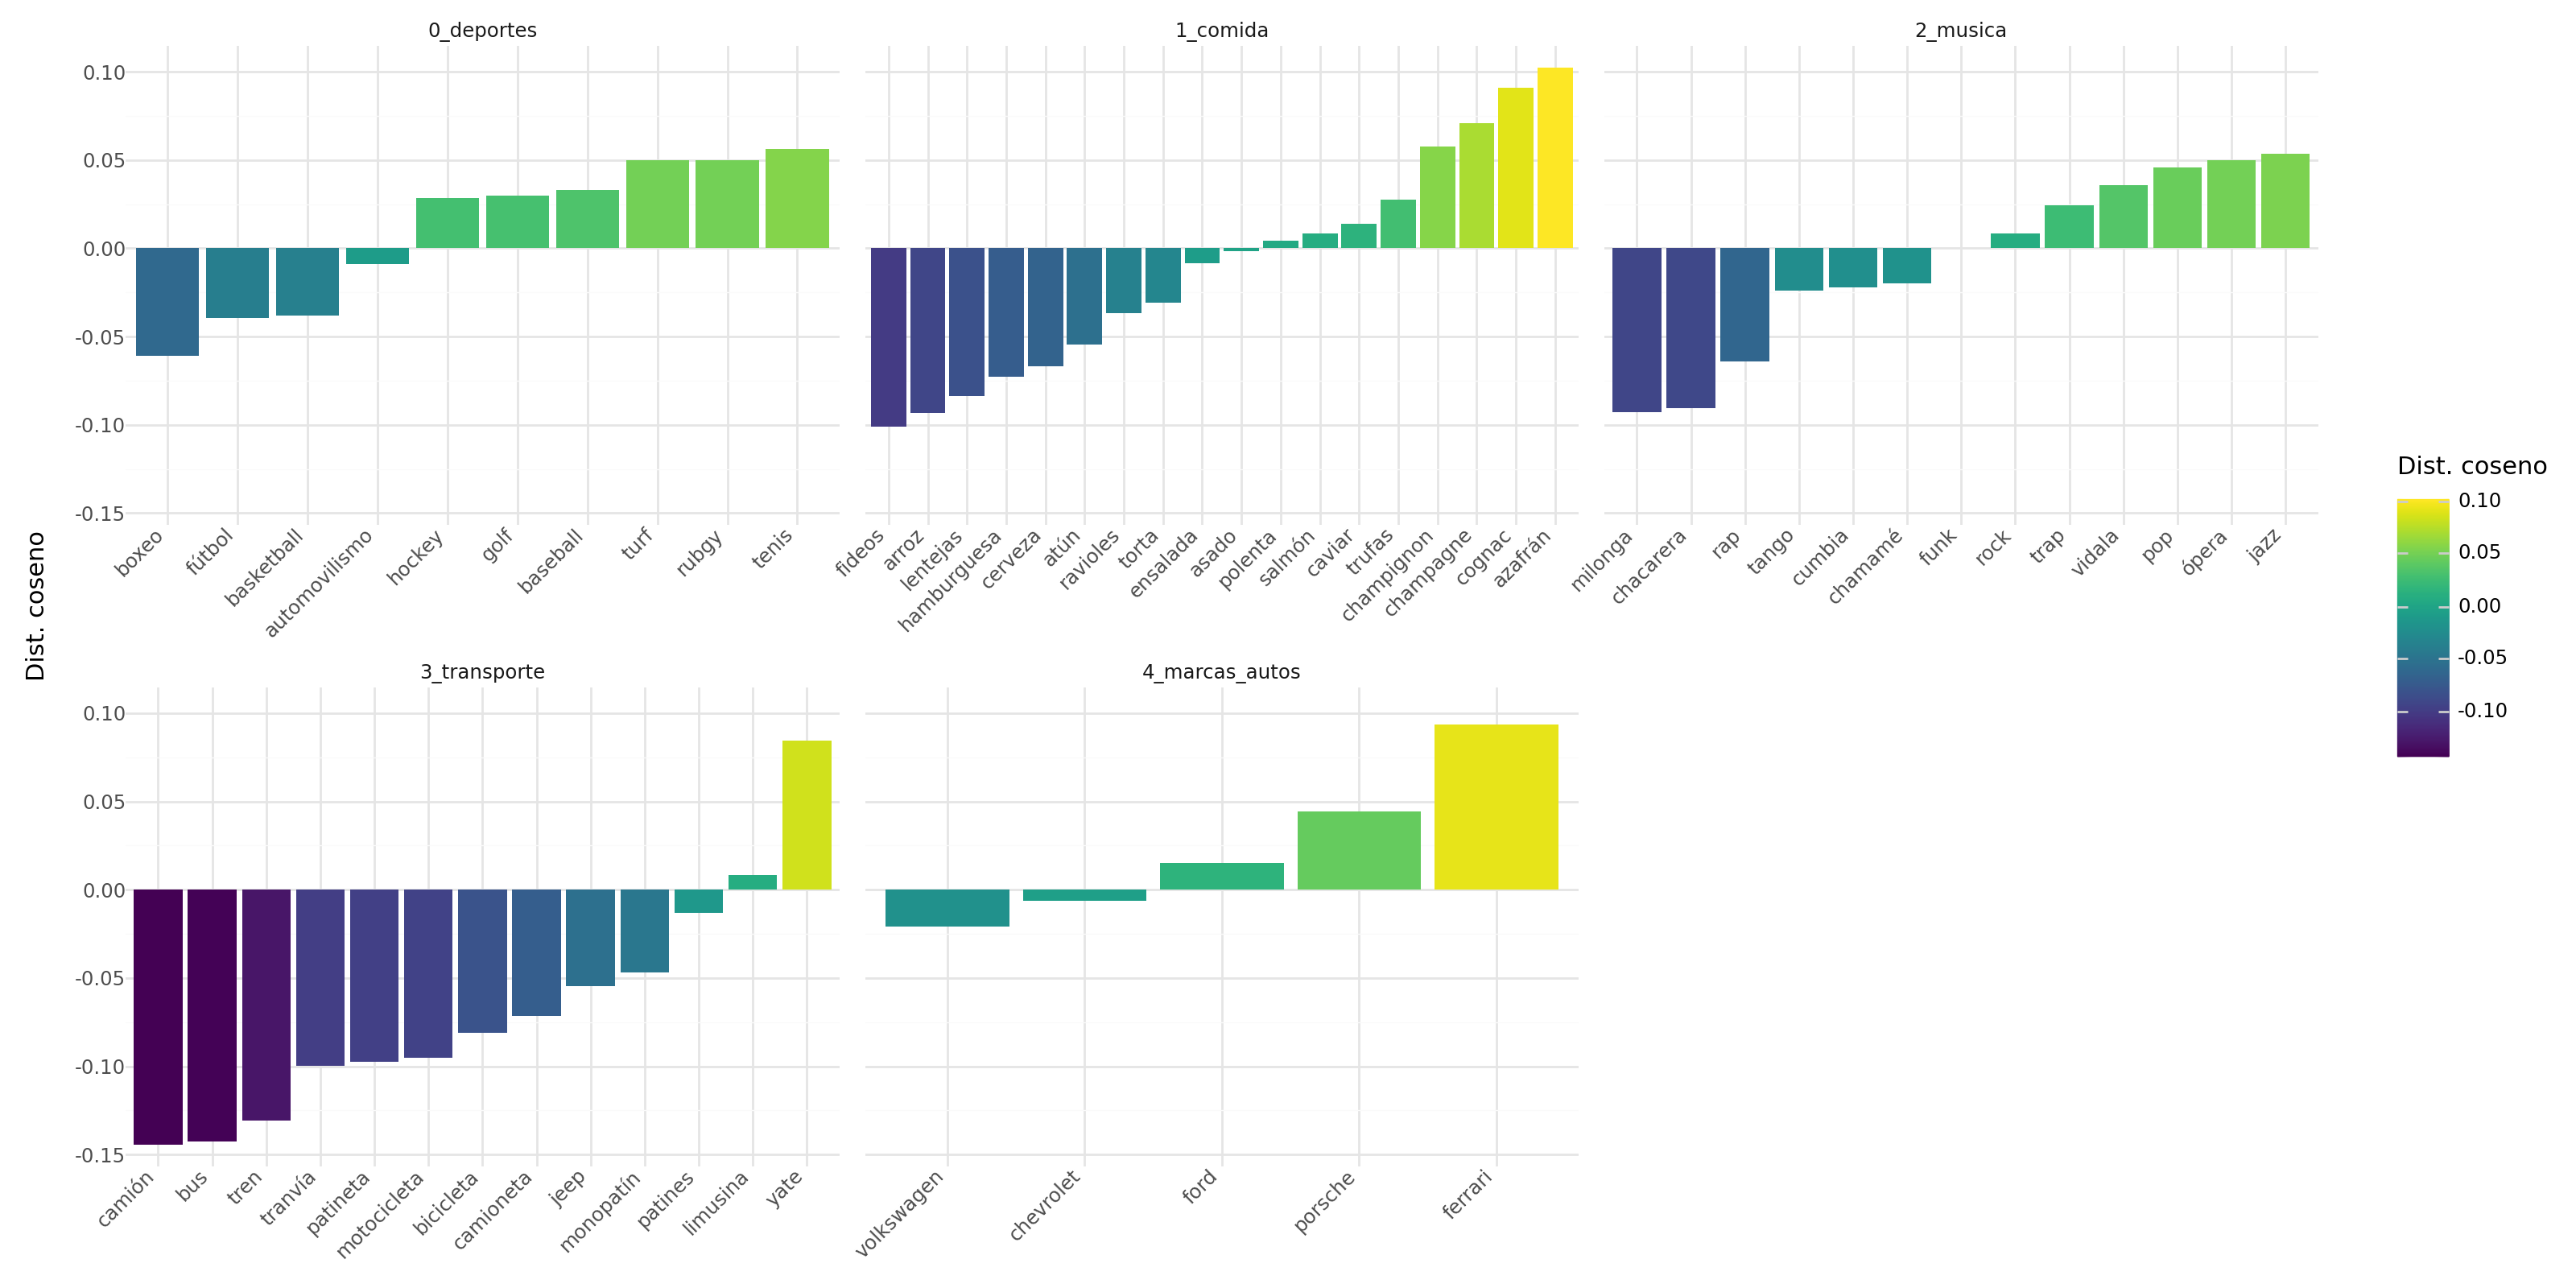

In [22]:
(
ggplot(df[df['dim'].isin(['1_comida', '0_deportes', '4_marcas_autos', '2_musica', '3_transporte'])])
  + geom_col(aes(x='reorder(word, cosine)', y="cosine", fill="cosine"))
  + facet_wrap("dim", scales="free_x")
  +   theme_minimal()
  + theme(axis_text_x=element_text(rotation=45, hjust=1), figure_size=(16, 8))
  + labs(x='',
         y="Dist. coseno",
         fill="Dist. coseno")

)